In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pgmpy.models import DiscreteBayesianNetwork as BayesianNetwork
from pgmpy.estimators import MaximumLikelihoodEstimator
from pgmpy.inference import VariableElimination


In [2]:
# Load heart disease dataset
df_raw = pd.read_csv('../data/heart.csv')

print('Dataset shape:', df_raw.shape)
print('\nColumns:', df_raw.columns.tolist())
print('\nFirst 5 rows:')
print(df_raw.head())
print('\nMissing values per column:')
print(df_raw.isna().sum())

Dataset shape: (1025, 14)

Columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

First 5 rows:
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  

Missing values per column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal       

In [3]:
# Preprocess and select important medical features
selected_cols = ['age', 'chol', 'trestbps', 'cp', 'thalach', 'target']
df = df_raw[selected_cols].copy()

# Handle missing values
for col in ['age', 'chol', 'trestbps', 'thalach']:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df[col] = df[col].fillna(df[col].median())

for col in ['cp', 'target']:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df[col] = df[col].fillna(df[col].mode().iloc[0]).astype(int)

# Convert continuous variables to categories for discrete BN
df['AgeGroup'] = pd.cut(
    df['age'],
    bins=[0, 40, 55, 120],
    labels=['young', 'middle', 'senior'],
    include_lowest=True
)

df['CholesterolLevel'] = pd.cut(
    df['chol'],
    bins=[0, 200, 240, 1000],
    labels=['normal', 'borderline_high', 'high'],
    include_lowest=True
)

df['BPLevel'] = pd.cut(
    df['trestbps'],
    bins=[0, 120, 140, 300],
    labels=['normal', 'elevated', 'high'],
    include_lowest=True
)

df['MaxHRLevel'] = pd.cut(
    df['thalach'],
    bins=[0, 120, 160, 260],
    labels=['low', 'normal', 'high'],
    include_lowest=True
)

cp_map = {
    0: 'typical_angina',
    1: 'atypical_angina',
    2: 'non_anginal_pain',
    3: 'asymptomatic'
}
df['ChestPainType'] = df['cp'].map(cp_map).fillna('asymptomatic')

# Final BN dataset
df_bn = df[['AgeGroup', 'CholesterolLevel', 'BPLevel', 'ChestPainType', 'MaxHRLevel', 'target']].copy()
df_bn = df_bn.rename(columns={'target': 'HeartDisease'})
df_bn['HeartDisease'] = df_bn['HeartDisease'].astype(int)

for col in ['AgeGroup', 'CholesterolLevel', 'BPLevel', 'ChestPainType', 'MaxHRLevel']:
    if df_bn[col].isna().any():
        df_bn[col] = df_bn[col].fillna(df_bn[col].mode().iloc[0])

print('Preprocessed data sample:')
print(df_bn.head())
print('\nCategory counts:')
for col in ['AgeGroup', 'CholesterolLevel', 'BPLevel', 'ChestPainType', 'MaxHRLevel', 'HeartDisease']:
    print(f'\n{col}')
    print(df_bn[col].value_counts())

Preprocessed data sample:
  AgeGroup CholesterolLevel   BPLevel   ChestPainType MaxHRLevel  HeartDisease
0   middle  borderline_high  elevated  typical_angina       high             0
1   middle  borderline_high  elevated  typical_angina     normal             0
2   senior           normal      high  typical_angina     normal             0
3   senior  borderline_high      high  typical_angina       high             0
4   senior             high  elevated  typical_angina        low             0

Category counts:

AgeGroup
AgeGroup
senior    519
middle    438
young      68
Name: count, dtype: int64

CholesterolLevel
CholesterolLevel
high               503
borderline_high    350
normal             172
Name: count, dtype: int64

BPLevel
BPLevel
elevated    479
normal      329
high        217
Name: count, dtype: int64

ChestPainType
ChestPainType
typical_angina      497
non_anginal_pain    284
atypical_angina     167
asymptomatic         77
Name: count, dtype: int64

MaxHRLevel
MaxHRLevel


In [4]:
# Define Bayesian Network structure and train with MLE
model = BayesianNetwork([
    ('AgeGroup', 'BPLevel'),
    ('AgeGroup', 'CholesterolLevel'),
    ('AgeGroup', 'HeartDisease'),
    ('BPLevel', 'HeartDisease'),
    ('CholesterolLevel', 'HeartDisease'),
    ('ChestPainType', 'HeartDisease'),
    ('MaxHRLevel', 'HeartDisease')
])

model.fit(df_bn, estimator=MaximumLikelihoodEstimator)

print('Bayesian Network structure (edges):')
print(list(model.edges()))
print('\nModel trained successfully with MLE.')
print('\nLearned CPDs (compact):')
for cpd in model.get_cpds():
    print(f"{cpd.variable}: shape={cpd.values.shape}")

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'AgeGroup': 'O', 'CholesterolLevel': 'O', 'BPLevel': 'O', 'ChestPainType': 'C', 'MaxHRLevel': 'O', 'HeartDisease': 'N'}


Bayesian Network structure (edges):
[('AgeGroup', 'BPLevel'), ('AgeGroup', 'CholesterolLevel'), ('AgeGroup', 'HeartDisease'), ('BPLevel', 'HeartDisease'), ('CholesterolLevel', 'HeartDisease'), ('ChestPainType', 'HeartDisease'), ('MaxHRLevel', 'HeartDisease')]

Model trained successfully with MLE.

Learned CPDs (compact):
AgeGroup: shape=(3,)
BPLevel: shape=(3, 3)
CholesterolLevel: shape=(3, 3)
HeartDisease: shape=(2, 3, 3, 4, 3, 3)
ChestPainType: shape=(4,)
MaxHRLevel: shape=(3,)


In [5]:
# Perform inference using Variable Elimination
inference = VariableElimination(model)

# Example patient
patient_evidence = {
    'AgeGroup': 'senior',
    'CholesterolLevel': 'high',
    'BPLevel': 'high',
    'ChestPainType': 'asymptomatic',
    'MaxHRLevel': 'low'
}

posterior = inference.query(variables=['HeartDisease'], evidence=patient_evidence)
print('Posterior distribution P(HeartDisease | evidence):')
print(posterior)

states = posterior.state_names['HeartDisease']
if 1 in states:
    pos_index = states.index(1)
elif '1' in states:
    pos_index = states.index('1')
else:
    pos_index = int(np.argmax(states))

prob_heart_disease = float(posterior.values[pos_index])
prob_no_disease = float(1.0 - prob_heart_disease)

diagnosis = 'Heart disease likely' if prob_heart_disease >= 0.50 else 'Heart disease unlikely'

print('\nPatient evidence:')
for k, v in patient_evidence.items():
    print(f'- {k}: {v}')

print(f'\nP(HeartDisease = 1): {prob_heart_disease:.4f}')
print(f'P(HeartDisease = 0): {prob_no_disease:.4f}')
print(f'Diagnosis result: {diagnosis}')

Posterior distribution P(HeartDisease | evidence):
+-----------------+---------------------+
| HeartDisease    |   phi(HeartDisease) |
+=================+=====================+
| HeartDisease(0) |              0.5000 |
+-----------------+---------------------+
| HeartDisease(1) |              0.5000 |
+-----------------+---------------------+

Patient evidence:
- AgeGroup: senior
- CholesterolLevel: high
- BPLevel: high
- ChestPainType: asymptomatic
- MaxHRLevel: low

P(HeartDisease = 1): 0.5000
P(HeartDisease = 0): 0.5000
Diagnosis result: Heart disease likely


In [6]:
# Reusable prediction function

def predict_heart_disease(evidence):
    posterior_local = inference.query(variables=['HeartDisease'], evidence=evidence)
    states_local = posterior_local.state_names['HeartDisease']

    if 1 in states_local:
        pos_index_local = states_local.index(1)
    elif '1' in states_local:
        pos_index_local = states_local.index('1')
    else:
        pos_index_local = int(np.argmax(states_local))

    p_yes = float(posterior_local.values[pos_index_local])
    p_no = float(1.0 - p_yes)
    diagnosis_local = 'Heart disease likely' if p_yes >= 0.50 else 'Heart disease unlikely'

    return {
        'posterior': posterior_local,
        'p_heart_disease': p_yes,
        'p_no_heart_disease': p_no,
        'diagnosis': diagnosis_local
    }


# Example prediction
example_patient = {
    'AgeGroup': 'middle',
    'CholesterolLevel': 'borderline_high',
    'BPLevel': 'elevated',
    'ChestPainType': 'non_anginal_pain',
    'MaxHRLevel': 'normal'
}

result = predict_heart_disease(example_patient)
print('Example patient evidence:', example_patient)
print(f"P(HeartDisease=1): {result['p_heart_disease']:.4f}")
print(f"P(HeartDisease=0): {result['p_no_heart_disease']:.4f}")
print('Diagnosis:', result['diagnosis'])

Example patient evidence: {'AgeGroup': 'middle', 'CholesterolLevel': 'borderline_high', 'BPLevel': 'elevated', 'ChestPainType': 'non_anginal_pain', 'MaxHRLevel': 'normal'}
P(HeartDisease=1): 0.5000
P(HeartDisease=0): 0.5000
Diagnosis: Heart disease likely


INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'AgeGroup': 'O', 'CholesterolLevel': 'O', 'BPLevel': 'O', 'ChestPainType': 'C', 'MaxHRLevel': 'O', 'HeartDisease': 'N'}


Performance metrics on test set:
Accuracy : 0.8521
Precision: 0.8672
Recall   : 0.8409
F1-Score : 0.8538
ROC-AUC  : 0.9298


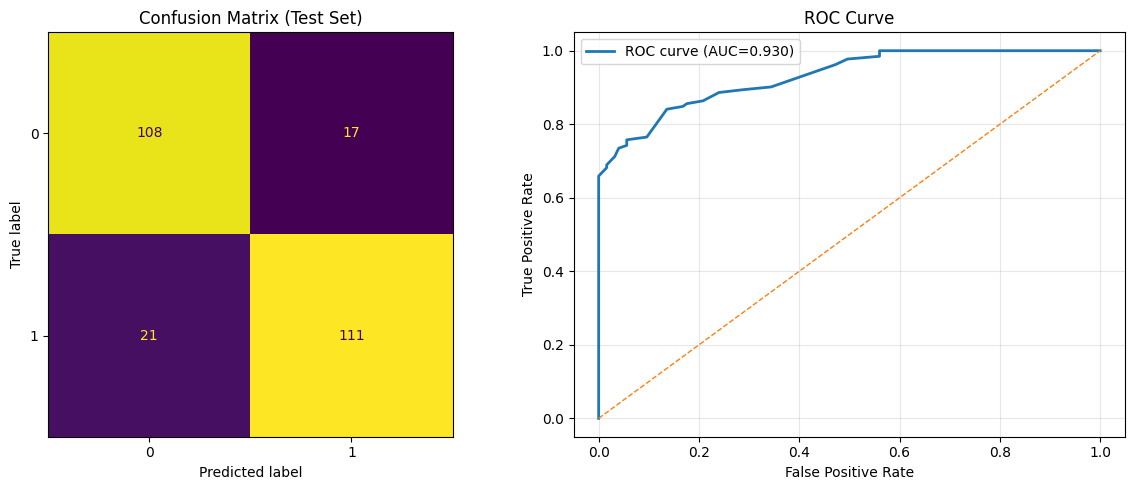

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve
)

# Test-set evaluation
X = df_bn[['AgeGroup', 'CholesterolLevel', 'BPLevel', 'ChestPainType', 'MaxHRLevel']]
y_true = df_bn['HeartDisease'].astype(int).values

X_train, X_test, y_train, y_test = train_test_split(
    X, y_true, test_size=0.25, random_state=42, stratify=y_true
)

train_df = X_train.copy()
train_df['HeartDisease'] = y_train

eval_model = BayesianNetwork([
    ('AgeGroup', 'BPLevel'),
    ('AgeGroup', 'CholesterolLevel'),
    ('AgeGroup', 'HeartDisease'),
    ('BPLevel', 'HeartDisease'),
    ('CholesterolLevel', 'HeartDisease'),
    ('ChestPainType', 'HeartDisease'),
    ('MaxHRLevel', 'HeartDisease')
])

eval_model.fit(train_df, estimator=MaximumLikelihoodEstimator)
eval_inference = VariableElimination(eval_model)

y_prob = []
for _, row in X_test.iterrows():
    q = eval_inference.query(variables=['HeartDisease'], evidence=row.to_dict())
    states = q.state_names['HeartDisease']
    if 1 in states:
        idx1 = states.index(1)
    elif '1' in states:
        idx1 = states.index('1')
    else:
        idx1 = int(len(states) - 1)
    y_prob.append(float(q.values[idx1]))

y_prob = np.array(y_prob)
y_pred = (y_prob >= 0.5).astype(int)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
auc = roc_auc_score(y_test, y_prob)

print('Performance metrics on test set:')
print(f'Accuracy : {acc:.4f}')
print(f'Precision: {prec:.4f}')
print(f'Recall   : {rec:.4f}')
print(f'F1-Score : {f1:.4f}')
print(f'ROC-AUC  : {auc:.4f}')

cm = confusion_matrix(y_test, y_pred)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(ax=axes[0], colorbar=False)
axes[0].set_title('Confusion Matrix (Test Set)')

fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, linewidth=2, label=f'ROC curve (AUC={auc:.3f})')
axes[1].plot([0, 1], [0, 1], linestyle='--', linewidth=1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()